In [1]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from colav_automaton import ColavAutomaton
from colav_automaton.integration import normalize_heading_in_results
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import numpy as np

In [2]:
# Imazu Case 1
ha: Automaton = ColavAutomaton(
    waypoint_x=500.0,
    waypoint_y=0.0,
    obstacle_x=200.0,
    obstacle_y=0.0,
    Cs=50.0,
    a=1.67,
    v=12.0,
    eta=3.5,
    tp=1.0
)


print(ha)

Hybrid Automaton Definition:
	name: COLAV Automaton
	id: 0
	initial_mode: WAYPOINT_REACHING
	modes: [WAYPOINT_REACHING, COLLISION_AVOIDANCE, CONSTANT_CONTROL]
	transitions:
		WAYPOINT_REACHING --[avoid]--> COLLISION_AVOIDANCE
		COLLISION_AVOIDANCE --[hold]--> CONSTANT_CONTROL
		CONSTANT_CONTROL --[resume]--> WAYPOINT_REACHING
	guards:
		avoid: [G11_and_G12_guard]
		hold: [L1_bar_or_L2_bar_guard]
		resume: [not_G11_guard]
	resets:
		avoid: reset_enter_avoidance
		hold: <none>
		resume: reset_exit_avoidance
	invariants:
		WAYPOINT_REACHING: [not_G11_guard]
		COLLISION_AVOIDANCE: [not_G11_guard]
		CONSTANT_CONTROL: [not_G11_guard]
	continous_dynamics:
		WAYPOINT_REACHING -> S1_waypoint_reaching_dynamics
		COLLISION_AVOIDANCE -> S2_collision_avoidance_dynamics
		CONSTANT_CONTROL -> S3_constant_control_dynamics



In [3]:
print(f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}")

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> WAYPOINT_REACHING
    WAYPOINT_REACHING --> COLLISION_AVOIDANCE: avoid
    COLLISION_AVOIDANCE --> CONSTANT_CONTROL: hold
    CONSTANT_CONTROL --> WAYPOINT_REACHING: resume


In [4]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
# Initial state: [x, y, psi]
await ha_runner.run(x0=np.array([0.0, 0.0, 0.0]), real_time_mode=False, integrate=True, duration=10.0, dt=0.01, collect_control=False, collect_auxiliary=False)

activating automaton 'COLAV Automaton'...
automaton 'COLAV Automaton' evaluation loop worker starting.
⚠️  S2: COLLISION_AVOIDANCE
🔄 S3: CONSTANT_CONTROL
🎯 S1: WAYPOINT_REACHING


{'continuous_states': [[0.01, array([0.12, 0.  , 0.  ])],
  [0.02, array([0.24, 0.  , 0.  ])],
  [0.03, array([0.36, 0.  , 0.  ])],
  [0.04, array([0.48, 0.  , 0.  ])],
  [0.05, array([0.6, 0. , 0. ])],
  [0.060000000000000005, array([0.72, 0.  , 0.  ])],
  [0.07, array([0.84, 0.  , 0.  ])],
  [0.08, array([0.96, 0.  , 0.  ])],
  [0.09, array([1.08, 0.  , 0.  ])],
  [0.09999999999999999, array([1.2, 0. , 0. ])],
  [0.10999999999999999, array([1.32, 0.  , 0.  ])],
  [0.11999999999999998, array([1.44, 0.  , 0.  ])],
  [0.12999999999999998, array([1.56, 0.  , 0.  ])],
  [0.13999999999999999, array([1.68, 0.  , 0.  ])],
  [0.15, array([1.8, 0. , 0. ])],
  [0.16, array([1.92, 0.  , 0.  ])],
  [0.17, array([2.04, 0.  , 0.  ])],
  [0.18000000000000002, array([2.16, 0.  , 0.  ])],
  [0.19000000000000003, array([2.28, 0.  , 0.  ])],
  [0.20000000000000004, array([2.4, 0. , 0. ])],
  [0.21000000000000005, array([2.52, 0.  , 0.  ])],
  [0.22000000000000006, array([2.64, 0.  , 0.  ])],
  [0.230000

In [5]:
print(repr(ha))

stateDiagram-v2
    direction LR
    [*] --> WAYPOINT_REACHING
    WAYPOINT_REACHING --> COLLISION_AVOIDANCE: avoid
    COLLISION_AVOIDANCE --> CONSTANT_CONTROL: hold
    CONSTANT_CONTROL --> WAYPOINT_REACHING: resume


/home/mstolberger/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


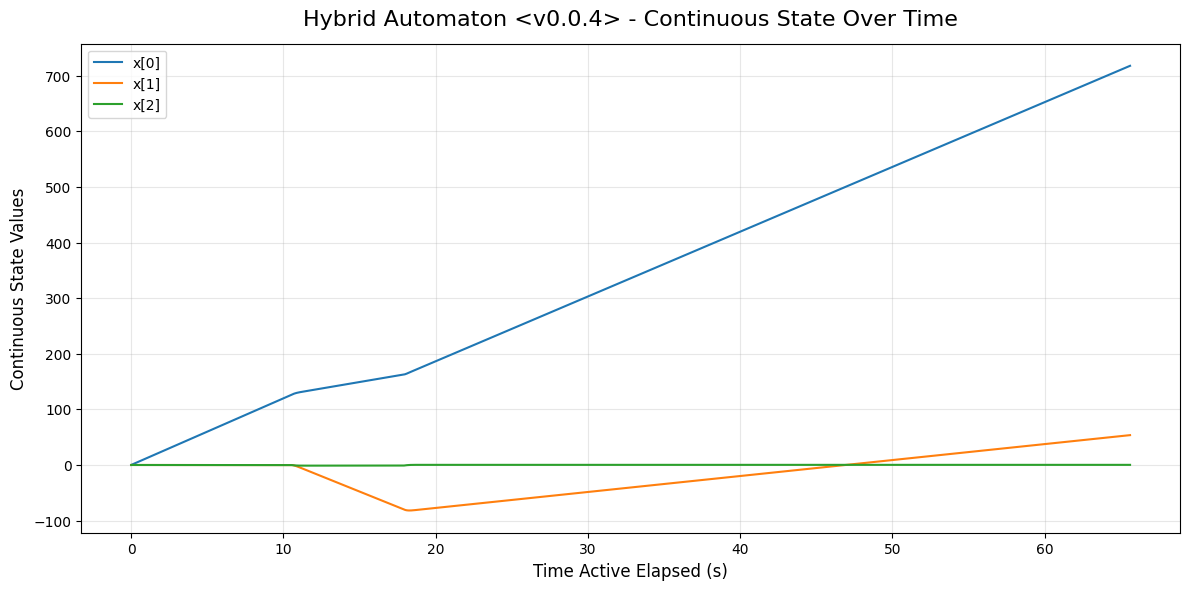

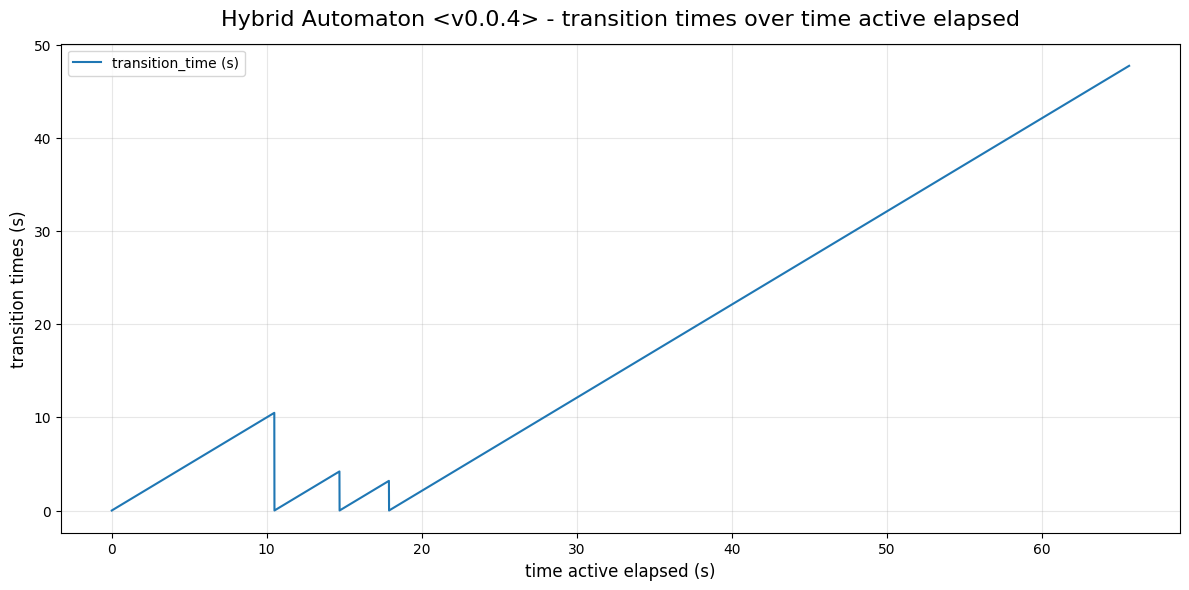

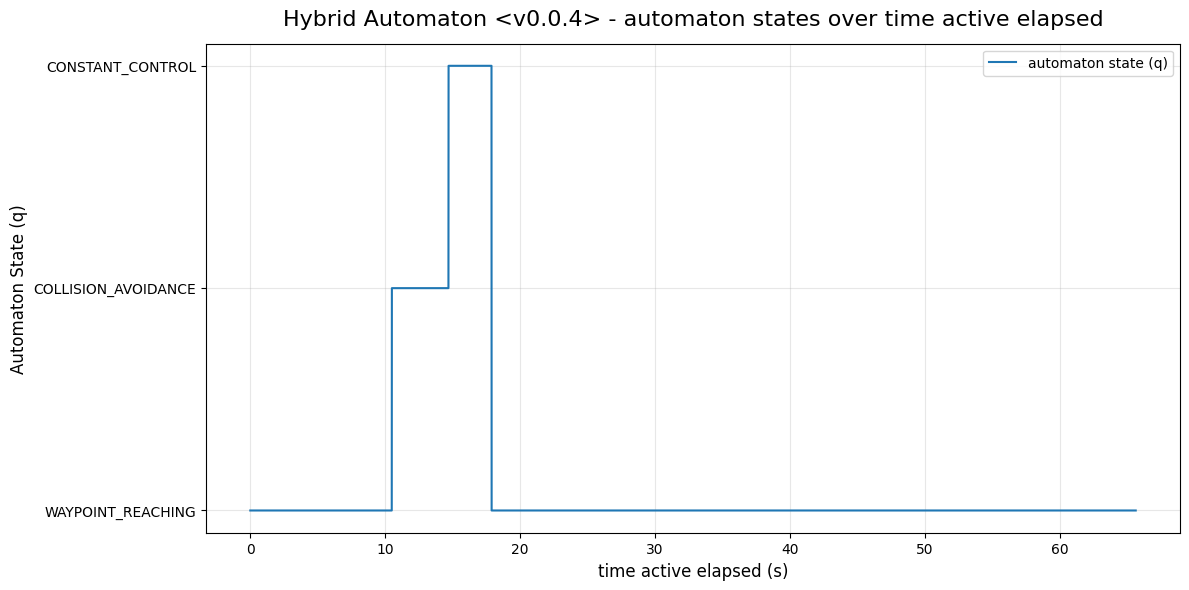

In [6]:
from hybrid_automaton_evaluation.figure_generator import continuous_states_over_time_fig, transitions_times_over_time_fig, automaton_states_over_time
import matplotlib.pyplot as plt

results = ha_runner.get_results()

# Normalize heading angles to [-π, π] for visualization
results = normalize_heading_in_results(results)

fig1 = continuous_states_over_time_fig(results['continuous_states'])
fig2 = transitions_times_over_time_fig(results['transition_times'])
fig3 = automaton_states_over_time(results['automaton_states'])

plt.show()

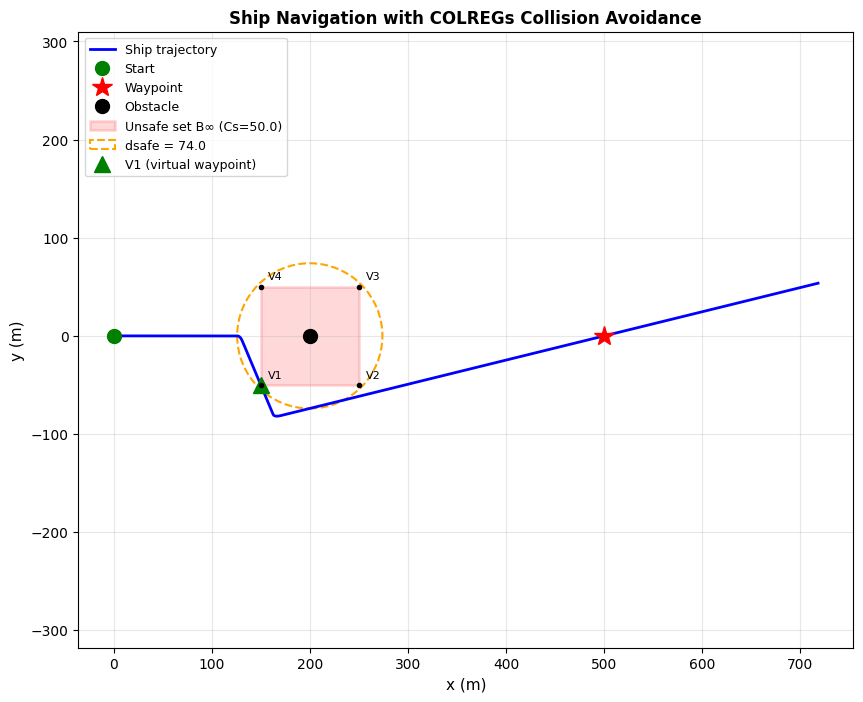


=== Simulation Results ===
Final position: (717.91, 53.68)
Distance to waypoint: 224.43 m
Minimum distance to obstacle: 65.43 m
Safe distance Cs: 50.0 m
Safety maintained: True


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from colav_automaton.integration import normalize_angle

results = ha_runner.get_results()

# Normalize heading angles to [-π, π] for visualization
results = normalize_heading_in_results(results)

states = results['continuous_states']

# Configuration (manually set since we know the values)
cfg = {
    'waypoint_x': 500.0,
    'waypoint_y': 0.0,
    'obstacle_x': 200.0,
    'obstacle_y': 0.0,
    'Cs': 50.0,
    'v': 12.0,
    'tp': 1.0,
}
# Match automaton.py calculation
cfg['dsafe'] = cfg['Cs'] + (cfg['v'] * 2) * cfg['tp']

x = [s[1][0] for s in states]
y = [s[1][1] for s in states]
t = [s[0] for s in states]

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(x, y, 'b-', linewidth=2, label='Ship trajectory')
ax.plot(0, 0, 'go', markersize=10, label='Start')
ax.plot(cfg['waypoint_x'], cfg['waypoint_y'], 'r*', markersize=15, label='Waypoint')

# Only draw obstacle if it's within reasonable range
if cfg['obstacle_x'] < 500 and cfg['obstacle_y'] < 500:
    ox, oy = cfg['obstacle_x'], cfg['obstacle_y']
    Cs = cfg['Cs']
    dsafe = cfg['dsafe']
    
    # Obstacle point
    ax.plot(ox, oy, 'ko', markersize=10, label='Obstacle')
    
    # Unsafe set
    unsafe_set = plt.Rectangle(
        (ox - Cs, oy - Cs), 2*Cs, 2*Cs,
        fill=True, facecolor='red', alpha=0.15,
        edgecolor='red', linestyle='-', linewidth=2, label=f'Unsafe set B∞ (Cs={Cs})'
    )
    ax.add_patch(unsafe_set)
    
    # Safe switching distance circle (dsafe = Cs + v*tp)
    safe_zone = plt.Circle(
        (ox, oy), dsafe,
        fill=False, edgecolor='orange', linestyle='--', linewidth=1.5, label=f'dsafe = {dsafe:.1f}'
    )
    ax.add_patch(safe_zone)
    
    # Virtual waypoint V1 (starboard corner - bottom left of unsafe set)
    v1_x, v1_y = ox - Cs, oy - Cs
    ax.plot(v1_x, v1_y, 'g^', markersize=12, label='V1 (virtual waypoint)')
    
    # Mark all 4 vertices of unsafe set
    vertices = [
        (ox - Cs, oy - Cs, 'V1'),
        (ox + Cs, oy - Cs, 'V2'),
        (ox + Cs, oy + Cs, 'V3'),
        (ox - Cs, oy + Cs, 'V4'),
    ]
    for vx, vy, name in vertices:
        ax.plot(vx, vy, 'k.', markersize=6)
        ax.annotate(name, (vx, vy), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('x (m)', fontsize=11)
ax.set_ylabel('y (m)', fontsize=11)
ax.set_title('Ship Navigation with COLREGs Collision Avoidance', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.show()

# Print key metrics
if cfg['obstacle_x'] < 500 and cfg['obstacle_y'] < 500:
    dist_to_obstacle = [np.sqrt((xi - ox)**2 + (yi - oy)**2) for xi, yi in zip(x, y)]
    print(f"\n=== Simulation Results ===")
    print(f"Final position: ({x[-1]:.2f}, {y[-1]:.2f})")
    print(f"Distance to waypoint: {np.sqrt((x[-1]-cfg['waypoint_x'])**2 + (y[-1]-cfg['waypoint_y'])**2):.2f} m")
    print(f"Minimum distance to obstacle: {min(dist_to_obstacle):.2f} m")
    print(f"Safe distance Cs: {Cs} m")
    print(f"Safety maintained: {min(dist_to_obstacle) >= Cs}")